In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_dir = "/content/drive/MyDrive/FishDataset/FishImgDataset"

In [ ]:
train_dataset = ImageFolder(root = f"{data_dir}/train", transform=transform)
val_dataset   = ImageFolder(root = f"{data_dir}/val", transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [ ]:
model = models.densenet121(pretrained=True)
for param in model.parameters():
    param.requires_grad = False
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 31)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 109MB/s] 


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

In [ ]:
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/10], Loss: 1.6471
Epoch [2/10], Loss: 0.7375
Epoch [3/10], Loss: 0.5491
Epoch [4/10], Loss: 0.4492
Epoch [5/10], Loss: 0.3885
Epoch [6/10], Loss: 0.3478
Epoch [7/10], Loss: 0.3142
Epoch [8/10], Loss: 0.2888
Epoch [9/10], Loss: 0.2703
Epoch [10/10], Loss: 0.2490


In [ ]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
print(f"Validation Accuracy: {100 * correct / total:.2f}%")


Validation Accuracy: 95.97%


In [ ]:
test_dataset = ImageFolder(root = f"{data_dir}/test", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 94.49%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

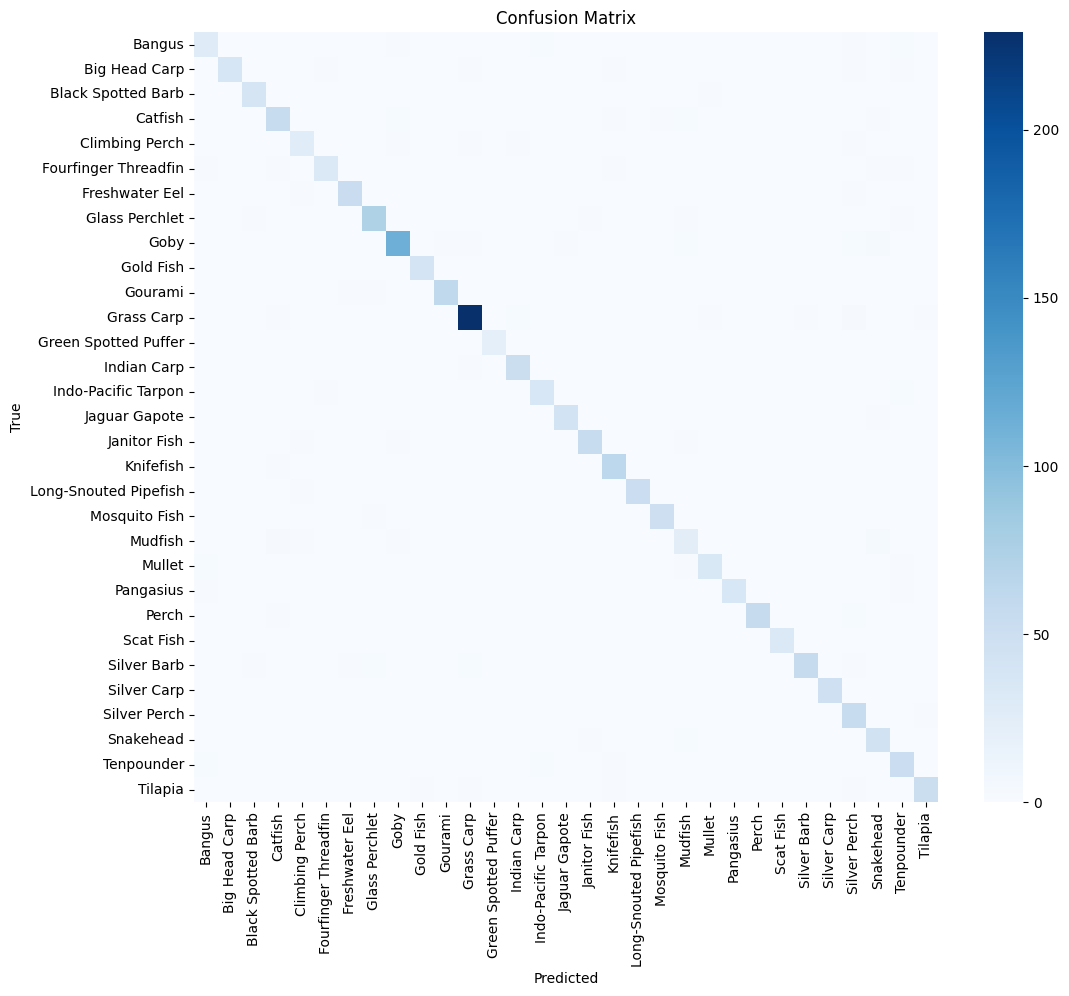

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

                       precision    recall  f1-score   support

               Bangus       0.82      0.82      0.82        34
        Big Head Carp       1.00      0.88      0.94        43
   Black Spotted Barb       0.95      0.97      0.96        40
              Catfish       0.89      0.89      0.89        62
       Climbing Perch       0.87      0.87      0.87        30
 Fourfinger Threadfin       0.94      0.87      0.90        38
       Freshwater Eel       0.96      0.96      0.96        55
       Glass Perchlet       0.95      0.95      0.95        77
                 Goby       0.95      0.91      0.93       124
            Gold Fish       0.98      1.00      0.99        41
              Gourami       0.98      0.97      0.98        63
           Grass Carp       0.97      0.96      0.97       238
 Green Spotted Puffer       1.00      1.00      1.00        22
          Indian Carp       0.95      0.98      0.96        53
  Indo-Pacific Tarpon       0.90      0.92      0.91  

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/densenet121_fish.pth")